<a href="https://colab.research.google.com/github/MMujtabaX/ngram-language-models/blob/main/ngram_language_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# N-gram Language Models: From Bigrams to 4-grams

An **n-gram language model** predicts the next word from the previous $n-1$ words:

$$P(w_i \mid w_1, \dots, w_{i-1}) \approx P(w_i \mid w_{i-n+1}, \dots, w_{i-1})$$

This is a Markov assumption of order $n-1$. More context should mean better predictions, but every extra word of context makes the counts **sparser**.

This notebook explores that trade-off:
1. **Warm-up:** a bigram next-word predictor on a handful of sentences, and a common bug
2. **Scaling up:** unigram → 4-gram models trained on three Jane Austen novels
3. **The sparsity problem:** how quickly longer n-grams become unseen
4. **Text generation:** what each order "sounds like", and when it starts copying
5. **Smoothing:** Laplace vs **Kneser-Ney**, compared by perplexity
6. **Autocomplete:** a working next-word suggester using backoff

In [1]:
import math
import random
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk import bigrams
from nltk.probability import FreqDist, ConditionalFreqDist

for pkg in ['punkt', 'punkt_tab', 'gutenberg']:
    nltk.download(pkg, quiet=True)

random.seed(42)

---
## 1. Warm-up: a Bigram Next-Word Predictor

A small corpus of everyday sentences. A bigram model counts which word follows which, then predicts the most frequent followers.

In [2]:
sentences = [
    "i want to travel world",
    "I am a good data scientist",
    "python is a great tool for data science",
    "learning NLP is challenging",
    "pleasant weather while traveling Islamabad",
    "NLP is fun",
    "i can do it",
    "I dont know and please don't tell me what is your name",
    "I think learning NLP is challenging",
    "i am enjoying",
    "i like to ride a bicycle in the morning",
    "I like to walk in the evening",
    "i am learning new habits",
]

tokens = [nltk.word_tokenize(s.lower()) for s in sentences]

### A common bug: bigrams across sentence boundaries

Flattening all sentences into one long token list before taking bigrams creates **fake bigrams** that join the last word of one sentence to the first word of the next:

In [3]:
flat_tokens = [w for sent in tokens for w in sent]
naive_bigrams = list(bigrams(flat_tokens))

boundary_bigrams = [(sentences[i].split()[-1].lower(), sentences[i + 1].split()[0].lower())
                    for i in range(len(sentences) - 1)]
fake = [bg for bg in naive_bigrams if bg in boundary_bigrams]
print(f"Bigrams from the flattened list: {len(naive_bigrams)}")
print(f"Fake cross-sentence bigrams:     {len(fake)}  e.g. {fake[:4]}")

Bigrams from the flattened list: 77
Fake cross-sentence bigrams:     12  e.g. [('world', 'i'), ('scientist', 'python'), ('science', 'learning'), ('challenging', 'pleasant')]


**The fix:** take bigrams *within* each sentence, and add `<s>` / `</s>` markers so the model also learns how sentences **start** and **end**.

In [4]:
padded = [['<s>'] + sent + ['</s>'] for sent in tokens]
bigrams_list = [bg for sent in padded for bg in bigrams(sent)]
conditional_freq = ConditionalFreqDist(bigrams_list)

def predict_next_token(word, k=3):
    """Return the k most likely next words after `word`, with their probabilities."""
    word = word.lower()
    if word not in conditional_freq:
        return []
    dist = conditional_freq[word]
    return [(w, round(c / dist.N(), 2)) for w, c in dist.most_common(k)]

for w in ['<s>', 'i', 'nlp', 'is', 'like', 'in']:
    print(f"{w!r:>8} -> {predict_next_token(w)}")

   '<s>' -> [('i', 0.69), ('python', 0.08), ('learning', 0.08)]
     'i' -> [('am', 0.33), ('like', 0.22), ('want', 0.11)]
   'nlp' -> [('is', 1.0)]
    'is' -> [('challenging', 0.4), ('a', 0.2), ('fun', 0.2)]
  'like' -> [('to', 1.0)]
    'in' -> [('the', 1.0)]


This works, but 13 sentences can't teach a model much about English. Let's scale up.

---
## 2. Scaling Up: Three Jane Austen Novels

*Emma*, *Persuasion* and *Sense and Sensibility* from NLTK's Gutenberg corpus give about 15,000 sentences. We hold out 10% to evaluate on.

Words seen fewer than twice in training are replaced by `<unk>`, so the model has a way to handle words it has never seen.

In [5]:
from nltk.corpus import gutenberg

BOS, EOS, UNK = '<s>', '</s>', '<unk>'

sents = []
for book in ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt']:
    for s in nltk.sent_tokenize(gutenberg.raw(book)):
        words = re.findall(r"[a-z]+(?:'[a-z]+)?", s.lower())
        if len(words) >= 3:
            sents.append(words)

random.shuffle(sents)
split = int(0.9 * len(sents))
train, test = sents[:split], sents[split:]

word_counts = Counter(w for s in train for w in s)
vocab = {w for w, c in word_counts.items() if c >= 2} | {EOS, UNK}

print(f"Sentences: {len(sents):,}  (train {len(train):,}, test {len(test):,})")
print(f"Training words: {sum(len(s) for s in train):,}   Vocabulary: {len(vocab):,}")

Sentences: 15,286  (train 13,757, test 1,529)
Training words: 328,255   Vocabulary: 6,538


In [6]:
def prepare(sentence, n):
    """Map rare words to <unk> and pad with n-1 start markers plus one end marker."""
    words = [w if w in vocab else UNK for w in sentence]
    return [BOS] * (n - 1) + words + [EOS]


class NGramCounts:
    """Raw n-gram counts for every order 1..n, stored as tables[k][context][word]."""

    def __init__(self, sentences, n):
        self.n = n
        self.tables = {k: defaultdict(Counter) for k in range(1, n + 1)}
        for s in sentences:
            toks = prepare(s, n)
            for i in range(n - 1, len(toks)):
                for k in range(1, n + 1):
                    self.tables[k][tuple(toks[i - k + 1:i])][toks[i]] += 1

counts = {n: NGramCounts(train, n) for n in [1, 2, 3, 4]}
for n in [1, 2, 3, 4]:
    distinct = sum(len(ws) for ws in counts[n].tables[n].values())
    print(f"{n}-gram: {distinct:>8,} distinct n-grams")

1-gram:    6,538 distinct n-grams
2-gram:  108,145 distinct n-grams
3-gram:  243,881 distinct n-grams
4-gram:  300,510 distinct n-grams


---
## 3. The Sparsity Problem

How many n-grams in the **held-out** text were never seen in training? If a model has never seen an n-gram, a pure count-based (MLE) model gives it probability zero.

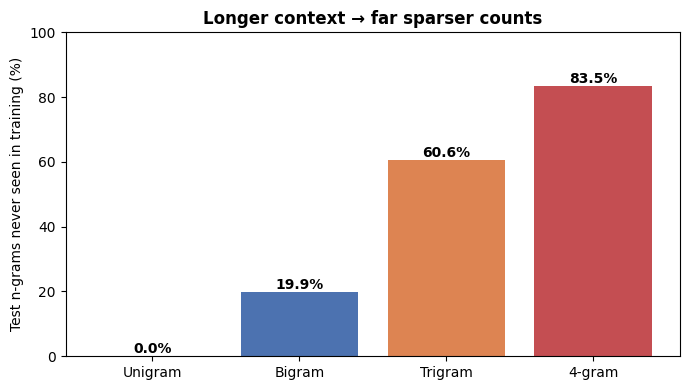

In [7]:
unseen_rates = {}
for n in [1, 2, 3, 4]:
    table = counts[n].tables[n]
    total = unseen = 0
    for s in test:
        toks = prepare(s, n)
        for i in range(n - 1, len(toks)):
            total += 1
            unseen += table.get(tuple(toks[i - n + 1:i]), {}).get(toks[i], 0) == 0
    unseen_rates[n] = unseen / total

labels = ['Unigram', 'Bigram', 'Trigram', '4-gram']
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [100 * unseen_rates[n] for n in [1, 2, 3, 4]],
               color=['#9AA5B1', '#4C72B0', '#DD8452', '#C44E52'])
plt.bar_label(bars, fmt='%.1f%%', fontweight='bold')
plt.ylabel('Test n-grams never seen in training (%)')
plt.title('Longer context → far sparser counts', fontweight='bold')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

- **Unigrams: 0% unseen**, because rare and new words are mapped to `<unk>`, which the model has seen.
- **Bigrams: about 1 in 5** test word pairs never appear in training.
- **4-grams: 83.5% are unseen**, even with 328,000 training words.

Language is creative: most longer word sequences are new. This is why higher-order models need **smoothing**.

---
## 4. Text Generation: What Does Each Order Sound Like?

Generate by repeatedly sampling the next word from the counts that follow the current context (the previous $n-1$ words).

In [8]:
def generate(n, max_words=25, seed=None):
    rng = random.Random(seed)
    table = counts[n].tables[n]
    context, out = [BOS] * (n - 1), []
    for _ in range(max_words):
        followers = table[tuple(context[-(n - 1):]) if n > 1 else ()]
        if n == 1:
            followers = Counter({w: c for w, c in followers.items() if w != UNK})
        word = rng.choices(list(followers), weights=list(followers.values()))[0]
        if word == EOS:
            break
        out.append(word)
        context.append(word)
    return " ".join(out)

for n, name in zip([1, 2, 3, 4], labels):
    print(f"--- {name} ---")
    for seed in range(3):
        print("  •", generate(n, seed=seed))
    print()

--- Unigram ---
  • equal great do it brandon and business looked much some amiable on you friendship such me disappointment invite song indulgence as him stay mine for
  • that diverted right it leisure with there russell
  • consent proud not

--- Bigram ---
  • well it
  • to mary does not look of amendment did not know is so droll if he said elinor enough quite as if you marianne
  • highbury included in the disclosure seldom really to miss smith she was that if not burn the least ashamed of a little distance from her

--- Trigram ---
  • well as her own doing
  • to do when it was impossible to last long
  • highbury that airy cheerful happy looking highbury would be off

--- 4-gram ---
  • well as you have borne it
  • to do the sort of necessity which the family habits seemed to produce of everything being to be done as to their sister's indisposition i
  • highbury that airy cheerful happy looking highbury would be his constant attraction



### Does a higher-order model copy its training data?

As $n$ grows, generated text gets more fluent. But is the model *creating* text or *replaying* it? We generate 200 sentences per order and check what fraction of their **5-word windows appear verbatim** in the training novels.

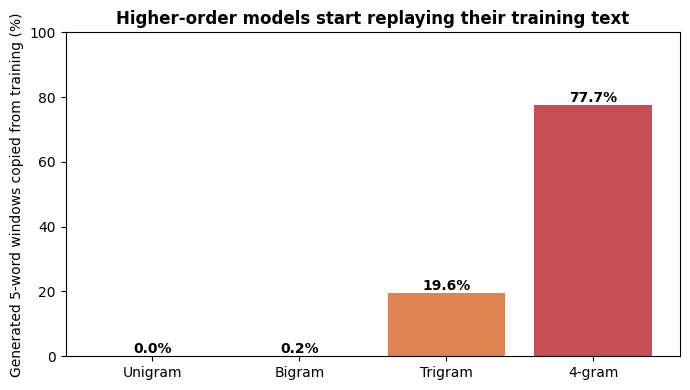

In [9]:
train_5grams = {tuple(s[i:i + 5]) for s in train for i in range(len(s) - 4)}

copy_rates = {}
for n in [1, 2, 3, 4]:
    windows = copied = 0
    for seed in range(200):
        words = generate(n, max_words=30, seed=1000 + seed).split()
        for i in range(len(words) - 4):
            windows += 1
            copied += tuple(words[i:i + 5]) in train_5grams
    copy_rates[n] = copied / windows if windows else 0

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [100 * copy_rates[n] for n in [1, 2, 3, 4]],
               color=['#9AA5B1', '#4C72B0', '#DD8452', '#C44E52'])
plt.bar_label(bars, fmt='%.1f%%', fontweight='bold')
plt.ylabel('Generated 5-word windows copied from training (%)')
plt.title('Higher-order models start replaying their training text', fontweight='bold')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

The bigram and trigram models produce mostly **new** word sequences. Only 0.2% and 19.6% of their 5-word windows exist in the novels. By the **4-gram, 77.7% of windows are copied verbatim**: with three words of context, most contexts were seen only once in training, so the model has just one option and replays the original sentence.

Fluency at high n is partly **memorization**. This is the same tension (generalizing vs memorizing training data) that matters for modern large language models.

---
## 5. Smoothing: Laplace vs Kneser-Ney

**Perplexity** measures how surprised a model is by held-out text (lower is better):

$$\text{PP} = \exp\Big(-\frac{1}{N}\sum_{i} \ln P(w_i \mid \text{context})\Big)$$

We compare two smoothing methods:

- **Laplace (add-1):** add 1 to every count. Simple, but it spreads probability evenly over the whole vocabulary.
- **Interpolated Kneser-Ney:** subtract a fixed discount ($d = 0.75$) from every seen n-gram and give that mass to a **lower-order model**. The lower orders use *continuation counts*: how many **different contexts** a word follows, not how often it appears.

> The classic Kneser-Ney example: "Francisco" is a frequent word, but it almost only ever follows "San". A plain unigram model would guess "Francisco" often; Kneser-Ney's continuation count knows it rarely starts a new pairing.

In [10]:
class LaplaceLM:
    def __init__(self, c):
        self.n, self.V = c.n, len(vocab)
        self.table = c.tables[c.n]
        self.totals = {h: sum(ws.values()) for h, ws in self.table.items()}

    def prob(self, word, context):
        h = tuple(context[-(self.n - 1):]) if self.n > 1 else ()
        return (self.table.get(h, {}).get(word, 0) + 1) / (self.totals.get(h, 0) + self.V)


class KneserNeyLM:
    """Interpolated Kneser-Ney with absolute discount d."""

    def __init__(self, c, d=0.75):
        self.n, self.d, self.V = c.n, d, len(vocab)
        self.tables = {self.n: c.tables[self.n]}          # highest order: raw counts
        for k in range(self.n - 1, 0, -1):                 # lower orders: continuation counts
            cont = defaultdict(Counter)
            for h, ws in c.tables[k + 1].items():
                for w in ws:
                    cont[h[1:]][w] += 1
            self.tables[k] = cont
        self.totals = {k: {h: sum(ws.values()) for h, ws in t.items()} for k, t in self.tables.items()}
        self.types = {k: {h: len(ws) for h, ws in t.items()} for k, t in self.tables.items()}

    def _p(self, word, h, k):
        if k == 0:
            return 1.0 / self.V                            # uniform base case
        total = self.totals[k].get(h, 0)
        lower = self._p(word, h[1:], k - 1)
        if total == 0:
            return lower                                   # unseen context: back off fully
        seen = self.tables[k][h].get(word, 0)
        lam = self.d * self.types[k][h] / total            # mass freed by discounting
        return max(seen - self.d, 0) / total + lam * lower

    def prob(self, word, context):
        h = tuple(context[-(self.n - 1):]) if self.n > 1 else ()
        return self._p(word, h, self.n)


def perplexity(model, sentences, n):
    log_sum, N = 0.0, 0
    for s in sentences:
        toks = prepare(s, n)
        for i in range(n - 1, len(toks)):
            log_sum += math.log(model.prob(toks[i], toks[i - n + 1:i] if n > 1 else []))
            N += 1
    return math.exp(-log_sum / N)

# Sanity check: Kneser-Ney probabilities over the vocabulary sum to 1
kn3 = KneserNeyLM(counts[3])
print("Sum of P(w | 'she was') over vocab:", round(sum(kn3.prob(w, ['she', 'was']) for w in vocab), 6))

Sum of P(w | 'she was') over vocab: 1.0


In [11]:
rows = []
for n, name in zip([1, 2, 3, 4], labels):
    rows.append({'model': name,
                 'Laplace': perplexity(LaplaceLM(counts[n]), test, n),
                 'Kneser-Ney': perplexity(KneserNeyLM(counts[n]), test, n) if n > 1 else np.nan})
pp = pd.DataFrame(rows).set_index('model')
pp.round(1)

,Laplace,Kneser-Ney
model,,
Unigram,466.4,NaN
Bigram,717.3,153.6
Trigram,3057.9,140.1
4-gram,4590.0,143.9


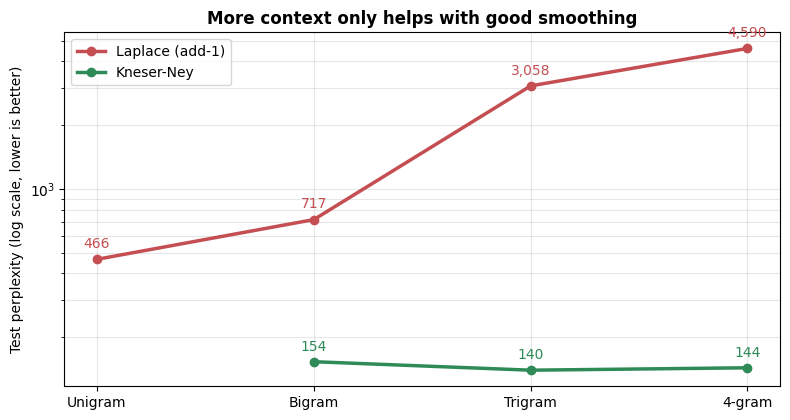

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(4)
ax.plot(x, pp['Laplace'], 'o-', lw=2.5, color='#C44E52', label='Laplace (add-1)')
ax.plot(x[1:], pp['Kneser-Ney'].iloc[1:], 'o-', lw=2.5, color='#2E8B57', label='Kneser-Ney')
for i, v in enumerate(pp['Laplace']):
    ax.annotate(f"{v:,.0f}", (i, v), textcoords='offset points', xytext=(0, 8), ha='center', color='#C44E52')
for i, v in enumerate(pp['Kneser-Ney'].iloc[1:], start=1):
    ax.annotate(f"{v:,.0f}", (i, v), textcoords='offset points', xytext=(0, 8), ha='center', color='#2E8B57')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_yscale('log')
ax.set_ylabel('Test perplexity (log scale, lower is better)')
ax.set_title('More context only helps with good smoothing', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

**What the chart shows:**
- **Laplace gets *worse* as n grows**, from 717 (bigram) to 4,590 (4-gram). Most higher-order contexts are rare, and add-1 hands nearly all of their probability to the ~6,500 words never seen after them.
- **Kneser-Ney is 5–30× better than Laplace** at every order, because discounting plus backoff to well-estimated lower orders handles sparsity gracefully.
- **The trigram is the sweet spot here** (perplexity 140). The 4-gram is slightly *worse* (144): with 83.5% of 4-grams unseen (Section 3), the extra context is mostly noise. Higher orders need much more data.

---
## 6. Autocomplete: Next-Word Suggestions with Backoff

A practical use of n-grams: suggest the next word as someone types. We use **stupid backoff** (Brants et al., 2007), the method Google used for web-scale n-gram models: try the longest context first; if it was never seen, back off to a shorter one, multiplying the score by 0.4 each time.

In [13]:
def suggest(text, n=4, k=3, alpha=0.4):
    """Top-k next-word suggestions for `text` using stupid backoff over orders n..1."""
    words = [w if w in vocab else UNK for w in re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())]
    context = [BOS] * (n - 1) + words
    scores, weight = Counter(), 1.0
    for order in range(n, 0, -1):
        h = tuple(context[-(order - 1):]) if order > 1 else ()
        followers = counts[n].tables[order].get(h)
        if followers:
            total = sum(followers.values())
            for w, c in followers.items():
                if w not in (EOS, UNK) and w not in scores:
                    scores[w] = weight * c / total
        if len(scores) >= k:
            break
        weight *= alpha
    return [w for w, _ in scores.most_common(k)]

prompts = ["she could not", "i am sure", "it was a", "my dear", "he was very", "in the course of", "mr", "elinor"]
pd.DataFrame({'You type': prompts, 'Suggestions': [", ".join(suggest(p)) for p in prompts]})

,You type,Suggestions
0,she could not,"be, but, help"
1,i am sure,"i, you, she"
2,it was a,"very, great, little"
3,my dear,"sir, emma, miss"
4,he was very,"much, clever, agreeable"
5,in the course of,"the, a, this"
6,mr,"knightley, weston, elton"
7,elinor,"was, could, had"


### Try it yourself (Colab / Jupyter)

Run the cell below and type a phrase to get live suggestions. Interactive widgets don't render on GitHub, so this cell only works when the notebook is opened in Colab or Jupyter.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    box = widgets.Text(placeholder='Start typing, e.g. "she was"', description='Text:')
    out = widgets.HTML()

    def on_change(change):
        out.value = "<b>Suggestions:</b> " + " · ".join(suggest(change['new'])) if change['new'].strip() else ""

    box.observe(on_change, names='value')
    display(box, out)
except ImportError:
    print("Install ipywidgets for the interactive demo: pip install ipywidgets")

---
## Summary

| Finding | Evidence |
|---------|----------|
| Longer n-grams are much sparser | 19.9% of test bigrams are unseen, vs 83.5% of 4-grams |
| Higher orders sound more fluent but start copying | 77.7% of the 4-gram's generated 5-word windows appear verbatim in the novels (bigram: 0.2%) |
| Smoothing determines whether context helps | Laplace perplexity rises from 717 to 4,590; Kneser-Ney stays at 140–154 |
| More context isn't always better | With 328K training words, trigram KN (140) beats 4-gram KN (144) |
| N-grams power real tools | Stupid-backoff autocomplete gives sensible suggestions instantly |

**Limitations:** n-grams can't generalize across similar words ("cat"/"dog") or remember anything beyond $n-1$ words. Neural language models solve both, using word embeddings and, later, attention over the entire context.